## IMPORT REQUIRED LIBRARIES 📚

In [872]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.preprocessing import LabelEncoder

pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = None

import warnings
warnings.filterwarnings('ignore')

In [873]:
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

---

## Load dataset 💽

In [874]:
try:
   df = pd.read_csv("data/used_cars.csv")
   print('- Data loaded ✅')
except:
    print('- Error data loading ❌')

- Data loaded ✅


---

In [875]:
print(f"\n📈 Dataset shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")


📈 Dataset shape: (4009, 12)
📋 Columns: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


In [876]:
print('===== First 5 row =====')
df.head()

===== First 5 row =====


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300.00"
1,Chevrolet,S-10 LS,2000,"133,510 mi.",E85 Flex Fuel,120.0HP 2.2L 4 Cylinder Engine Flex Fuel Capability,A/T,Blue,Black,None reported,Yes,"$4,500.00"
2,Audi,Q5 2.0T Premium Plus,2017,"81,880 mi.",E85 Flex Fuel,2.0L I4 16V GDI DOHC Turbo Flexible Fuel,8-Speed Automatic,Mythos Black Metallic,Black,None reported,Yes,"$21,375.00"
3,Bentley,Continental GTC Base,2011,"20,200 mi.",E85 Flex Fuel,552.0HP 6.0L 12 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,None reported,Yes,"$79,950.00"
4,Ford,Utility Police Interceptor Base,2013,"105,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,A/T,White,Black,At least 1 accident or damage reported,Yes,"$6,600.00"


In [877]:
print('===== last 5 row =====')
df.tail(5)

===== last 5 row =====


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Tesla,Model Y Long Range,2021,"49,252 mi.",NaN,Electric,1-Speed Automatic,Deep Blue Metallic,Black,None reported,NaN,"$37,999.00"
4005,Tesla,Model S 100D,2018,"65,000 mi.",NaN,518.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,"$41,000.00"
4006,Tesla,Model X Performance,2020,"25,535 mi.",NaN,778.0HP Electric Motor Electric Fuel System,A/T,White,Beige,None reported,Yes,"$68,969.00"
4007,Tesla,Model 3 Long Range,2021,"23,749 mi.",NaN,Electric,1-Speed Automatic,White,Black,None reported,NaN,"$35,999.00"
4008,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998.00"


In [878]:
print("📊 DATASET INFORMATION:")
print("="*40)
df.info()

📊 DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [879]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [880]:
df['price'] = (df['price'].str.replace('$', '', regex=False).str.replace(',', '',regex=False).astype(float))
print(df['price'].head())
print(f'Min: {df['price'].min()} | Max: {df['price'].max()}')

0    10300.0
1     4500.0
2    21375.0
3    79950.0
4     6600.0
Name: price, dtype: float64
Min: 2000.0 | Max: 2954083.0


In [881]:
df['milage'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex= False).astype('Int64')
print(df['milage'].head())
print(f'Min: {df['milage'].min()} | Max: {df['milage'].max()}')

0     51000
1    133510
2     81880
3     20200
4    105000
Name: milage, dtype: Int64
Min: 100 | Max: 405000


In [882]:
df['car_age'] = date.today().year - df['model_year']
pd.DataFrame({
    'Model Year' : df['model_year'],
    'Car Age': df['car_age']
}).sample(5)

,Model Year,Car Age
327,2019,7
1771,2010,16
2450,2006,20
3950,2022,4
3960,2020,6


---

## Filling NaN values ✅

In [883]:
df = df.replace('–', np.nan)

In [884]:
missing_data = df.isnull().sum()
missing_percent_rep = (missing_data / len(df)) * 100
missing_value = pd.DataFrame({
    'Missing Data': missing_data,
    'Missing Percent': round(missing_percent_rep,2)
})
print('❌ Missing value:')
print('='*40)
missing_value

❌ Missing value:


,Missing Data,Missing Percent
brand,0,0.00
model,0,0.00
model_year,0,0.00
milage,0,0.00
fuel_type,215,5.36
engine,45,1.12
transmission,4,0.10
ext_col,15,0.37
int_col,133,3.32
accident,113,2.82


* ### Filling fuel type, accident, clean title ✔️

In [885]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('Unknown')
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine           45
transmission      4
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling engine ✔️

In [886]:
initial_rows = len(df)
# first stage
df['engine'] = df['engine'].fillna(df.groupby(['brand', 'model'])['engine'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# second stage
df['engine'] = df['engine'].fillna(df.groupby('brand')['engine'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# third stage
df = df.dropna(subset=['engine'])

removed_rows = initial_rows - len(df)

print(f"✓ Grouped engine cleaning completed.")
print(f"✓ Number of cars completely removed in the third layer: {removed_rows} rows")
print(f"✓ Number of remaining data points in the dataset: {len(df)} \n")
print('=====isnull=====')
df.isnull().sum()

✓ Grouped engine cleaning completed.
✓ Number of cars completely removed in the third layer: 0 rows
✓ Number of remaining data points in the dataset: 4009 

=====isnull=====


brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      4
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling transmission ✔️

In [887]:
df[df['transmission'].isna()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
588,Porsche,911 Carrera S,2017,16701,Gasoline,3.0 Liter,NaN,Red,NaN,None reported,Unknown,107998.0,9
903,Porsche,911 Carrera 4S,2018,31678,Gasoline,3.0 Liter,NaN,Silver,NaN,None reported,Unknown,106798.0,8
3797,Ford,Bronco,1974,6217,Gasoline,2.7L V6 24V PDI DOHC Twin Turbo,NaN,Dark Gray Metallic,NaN,None reported,Yes,115000.0,52
3808,Rolls-Royce,Phantom,2023,1560,Gasoline,6.8L V12 48V GDI DOHC Twin Turbo,NaN,Tempest,Cobalt Blue,None reported,Yes,599995.0,3


In [888]:
initial_rows_trans = len(df)
# first stage
df['transmission'] = df['transmission'].fillna(
    df.groupby(['brand', 'model', 'engine'])['transmission'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# second stage
df['transmission'] = df['transmission'].fillna(
    df.groupby(['brand', 'model'])['transmission'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# third stage
df = df.dropna(subset=['transmission'])

removed_rows_trans = initial_rows_trans - len(df)

print(f"✓ Cascading transmission cleaning completed successfully.")
print(f"✓ Number of cars removed in the final layer: {removed_rows_trans} rows")
print(f"✓ Number of remaining data points in the entire dataset: {len(df)} \n")
print('=====isnull=====')
df.isnull().sum()

✓ Cascading transmission cleaning completed successfully.
✓ Number of cars removed in the final layer: 0 rows
✓ Number of remaining data points in the entire dataset: 4009 

=====isnull=====


brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling ext col & int col with "Unknown" ✔️

In [889]:
df['ext_col'] = df['ext_col'].fillna('Unknown')
df['int_col'] = df['int_col'].fillna('Unknown')

print("Final status of missing values in the entire dataset:")
print(df.isnull().sum())

Final status of missing values in the entire dataset:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
car_age         0
dtype: int64


## Outlier

In [890]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_len = len(df)
df = df[(df['price'] >= lower) & (df['price'] <= upper)]
after_len = len(df)

print(f'Rows removed due to outliers: {before_len - after_len}')
print(f'Remaining price range {df['price'].min():,.0f} — ${df['price'].max():,.0f}')
print(f'Data shape: {df.shape}')

Rows removed due to outliers: 244
Remaining price range 2,000 — $99,000
Data shape: (3765, 13)


In [891]:
df['accident_binary'] = df['accident'].apply(lambda x: 1 if 'At least' in str(x) else 0)
df['clean_title_binary'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)
pd.DataFrame({
    'Accident' : df['accident'].head(5),
    'Accident Binary' : df['accident_binary'].head(5),
    'Clean Title' : df['clean_title'].head(5),
    'Clean Title Binary' : df['clean_title_binary'].head(5)
})

,Accident,Accident Binary,Clean Title,Clean Title Binary
0,At least 1 accident or damage reported,1,Yes,1
1,None reported,0,Yes,1
2,None reported,0,Yes,1
3,None reported,0,Yes,1
4,At least 1 accident or damage reported,1,Yes,1


In [892]:
df.shape

(3765, 15)

In [893]:
cat_cols = ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Column {col} successfully encoded ✓")
print("New dimensions of data:", df.shape)

Column brand successfully encoded ✓
Column fuel_type successfully encoded ✓
Column transmission successfully encoded ✓
Column ext_col successfully encoded ✓
Column int_col successfully encoded ✓
New dimensions of data: (3765, 20)


In [894]:
df.sample(3)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,accident_binary,clean_title_binary,brand_enc,fuel_type_enc,transmission_enc,ext_col_enc,int_col_enc
1654,Porsche,Panamera 2,2011,37200,Gasoline,300.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,27500.0,15,0,1,39,2,20,20,9
2631,Jeep,Wagoneer Series III,2022,9099,Gasoline,5.7L V8 16V MPFI OHV,8-Speed Automatic,Velvet Red Pearlcoat,Global Black,None reported,Yes,68362.0,4,0,1,20,2,26,257,53
3228,Chevrolet,Corvette Stingray w/2LT,2022,2010,Gasoline,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Gray,Brown,None reported,Yes,89000.0,4,0,1,8,2,51,104,23


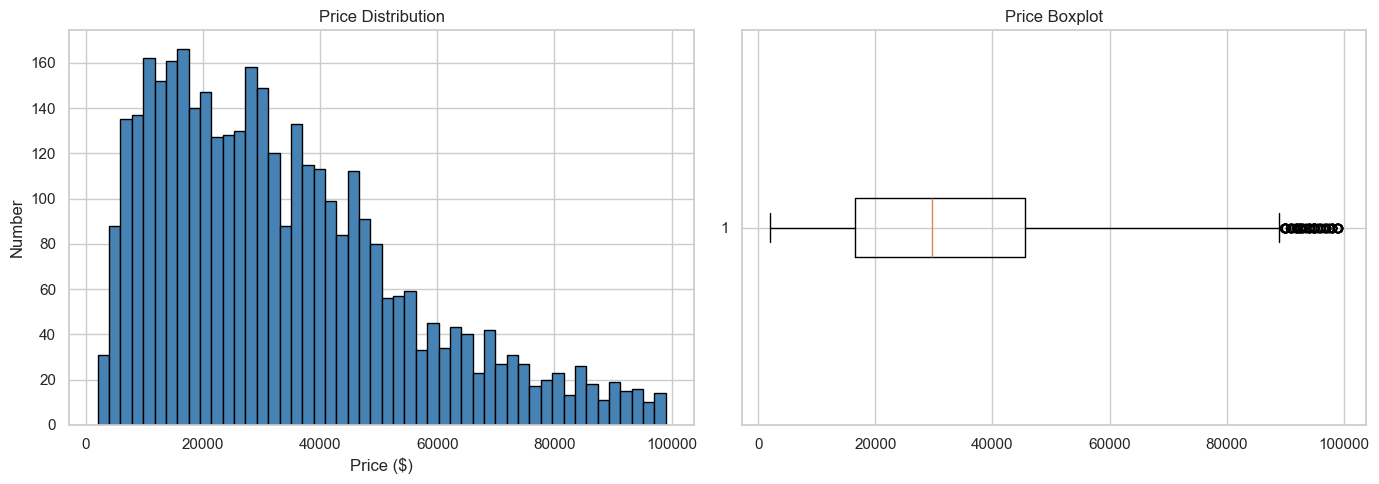

In [895]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number')

axes[1].boxplot(df['price'], vert=False)
axes[1].set_title('Price Boxplot')

plt.tight_layout()
plt.savefig('reports/01_price_distribution.png', dpi=450)
plt.show()

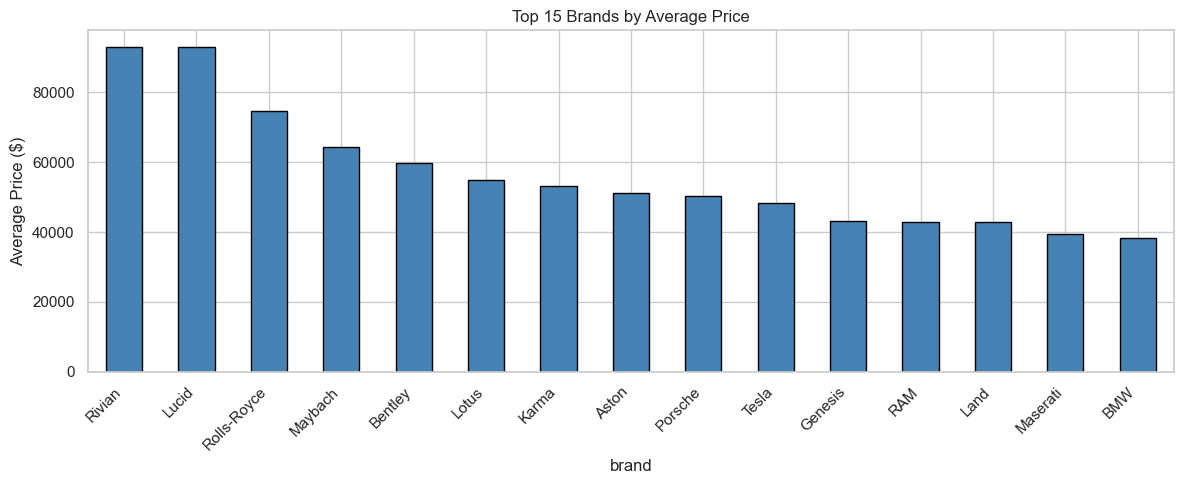

In [897]:
top_brands = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
top_brands.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Brands by Average Price')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/02_brand_price.png', dpi=450)
plt.show()

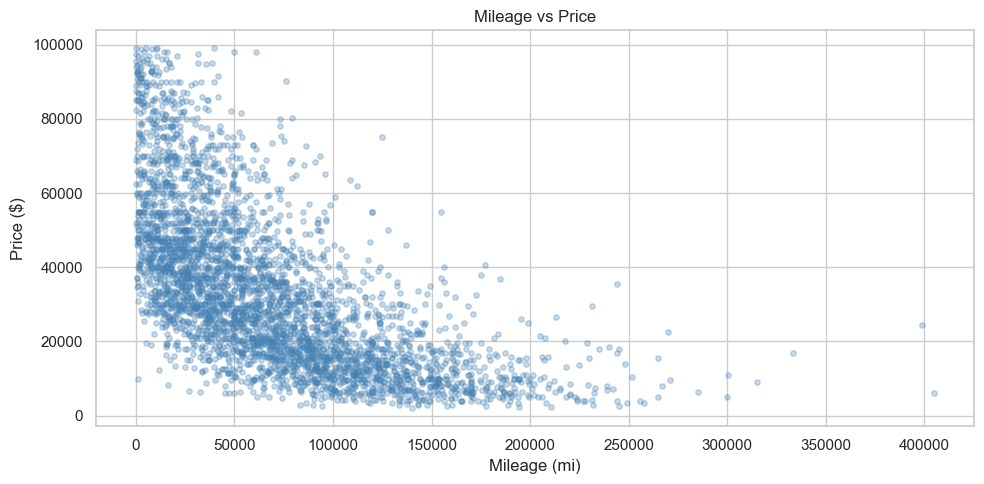

In [898]:
plt.figure(figsize=(10, 5))
plt.scatter(df['milage'], df['price'], alpha=0.3, color='steelblue', s=15)
plt.title('Mileage vs Price')
plt.xlabel('Mileage (mi)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('reports/03_mileage_vs_price.png', dpi=450)
plt.show()

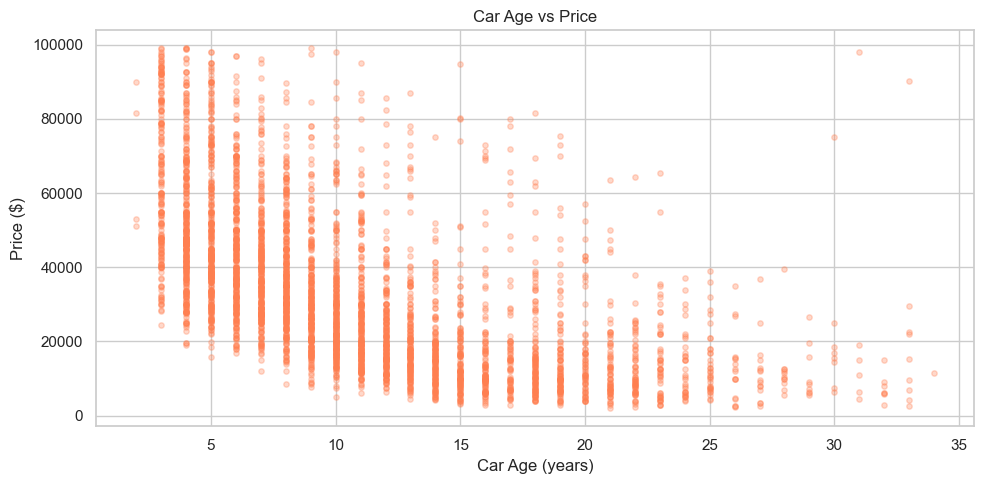

In [899]:
plt.figure(figsize=(10, 5))
plt.scatter(df['car_age'], df['price'], alpha=0.3, color='coral', s=15)
plt.title('Car Age vs Price')
plt.xlabel('Car Age (years)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('reports/04_age_vs_price.png', dpi=450)
plt.show()

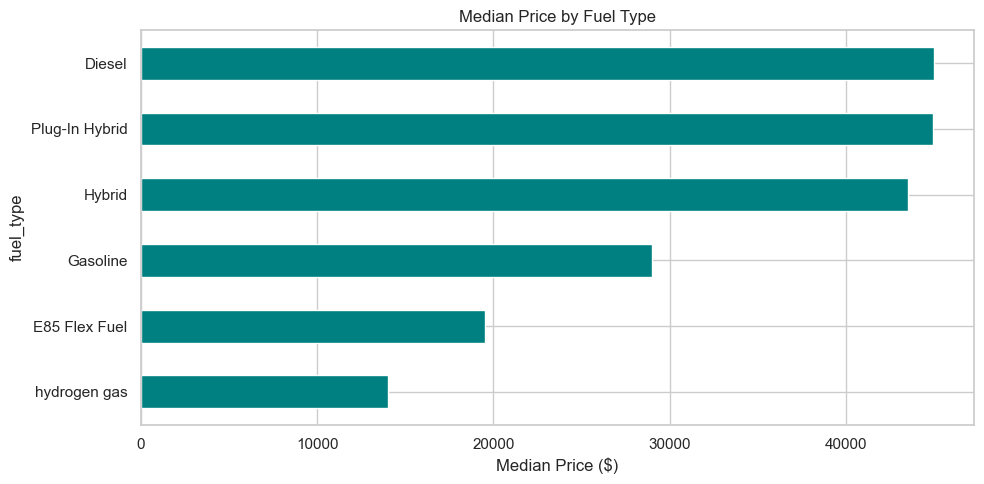

In [900]:
plt.figure(figsize=(10, 5))
df.groupby('fuel_type')['price'].median().sort_values().plot(
    kind='barh', color='teal', edgecolor='white')
plt.title('Median Price by Fuel Type')
plt.xlabel('Median Price ($)')
plt.tight_layout()
plt.savefig('reports/05_fuel_price.png', dpi=150)
plt.show()

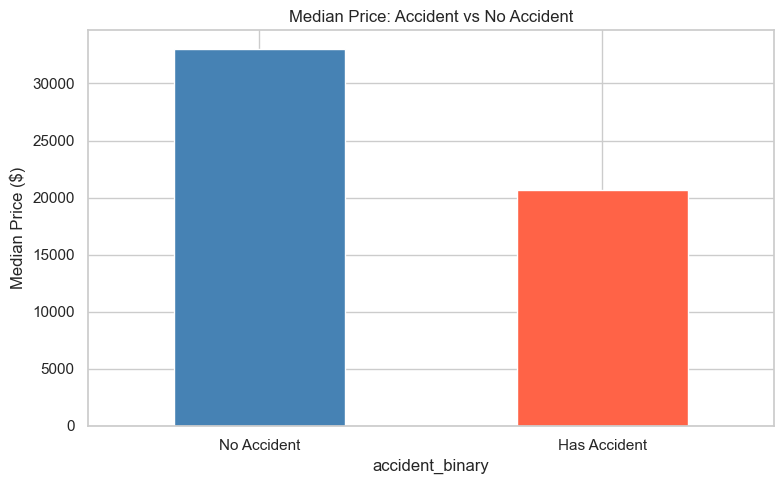

In [904]:
plt.figure(figsize=(8, 5))
df.groupby('accident_binary')['price'].median().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
plt.xticks([0, 1], ['No Accident', 'Has Accident'], rotation=0)
plt.title('Median Price: Accident vs No Accident')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.savefig('reports/06_accident_price.png', dpi=450)
plt.show()

In [907]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'car_age', 'accident_binary', 'clean_title_binary',
       'brand_enc', 'fuel_type_enc', 'transmission_enc', 'ext_col_enc',
       'int_col_enc'],
      dtype='object')

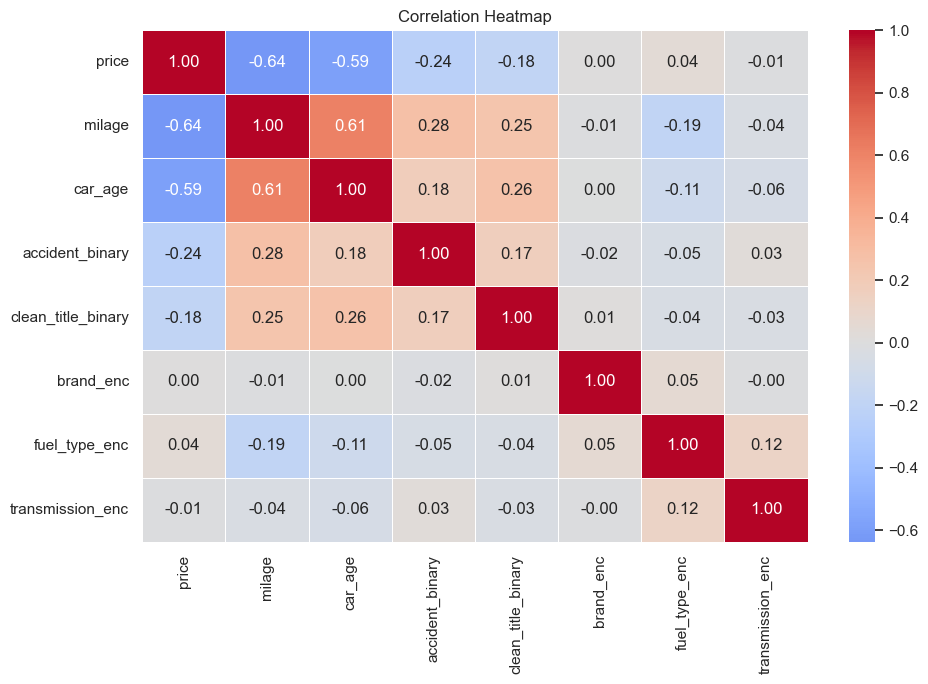

In [908]:
num_cols = ['price', 'milage', 'car_age', 'accident_binary',
            'clean_title_binary', 'brand_enc', 'fuel_type_enc', 'transmission_enc']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('reports/07_correlation_heatmap.png', dpi=450)
plt.show()